In [1]:
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

In [2]:
STATIONS = {
    "2590100": {"name": "SENOSHITA",    "river": "CHIKUGO GAWA",  "area": 2315.0, "lat": 33.3161, "lon": 130.4972},
    "2590101": {"name": "ARASE",        "river": "CHIKUGO GAWA",  "area": 1443.0, "lat": 33.3433, "lon": 130.8350},
    "2590200": {"name": "HINODE-BASHI", "river": "ONGA GAWA",     "area":  695.0, "lat": 33.7500, "lon": 130.7300},
    "2590210": {"name": "MUTABE",       "river": "MATSUURA GAWA", "area":  275.0, "lat": 33.3600, "lon": 130.0100},
    "2590220": {"name": "TAMANA",       "river": "KIKUCHI GAWA",  "area":  906.0, "lat": 32.9400, "lon": 130.5900},
    "2590230": {"name": "ONOBUCHI",     "river": "SENDAI GAWA",   "area": 1348.0, "lat": 31.8600, "lon": 130.3400},
    "2590300": {"name": "YOKOISHI",     "river": "KUMA GAWA",     "area": 1856.0, "lat": 32.4600, "lon": 130.6600},
    "2590301": {"name": "HITOYOSHI",    "river": "KUMA GAWA",     "area": 1137.0, "lat": 32.2100, "lon": 130.7700},
    "2590400": {"name": "KASHIWADA",    "river": "OYODO GAWA",    "area": 2126.0, "lat": 31.9500, "lon": 131.4000},
    "2590401": {"name": "HIWATASHI",    "river": "OYODO GAWA",    "area":  860.6, "lat": 31.8600, "lon": 131.1000},
}

TOPOLOGY = {
    "2590101": "2590100",  # ARASE      -> SENOSHITA  (Chikugo)
    "2590301": "2590300",  # HITOYOSHI  -> YOKOISHI   (Kuma)
    "2590401": "2590400",  # HIWATASHI  -> KASHIWADA  (Oyodo)
}

meta_df = pd.DataFrame(STATIONS).T
meta_df["area"] = meta_df["area"].astype(float)
meta_df.index.name = "station_id"
print(meta_df[["name", "river", "area", "lat", "lon"]])

                    name          river    area      lat       lon
station_id                                                        
2590100        SENOSHITA   CHIKUGO GAWA  2315.0  33.3161  130.4972
2590101            ARASE   CHIKUGO GAWA  1443.0  33.3433   130.835
2590200     HINODE-BASHI      ONGA GAWA   695.0    33.75    130.73
2590210           MUTABE  MATSUURA GAWA   275.0    33.36    130.01
2590220           TAMANA   KIKUCHI GAWA   906.0    32.94    130.59
2590230         ONOBUCHI    SENDAI GAWA  1348.0    31.86    130.34
2590300         YOKOISHI      KUMA GAWA  1856.0    32.46    130.66
2590301        HITOYOSHI      KUMA GAWA  1137.0    32.21    130.77
2590400        KASHIWADA     OYODO GAWA  2126.0    31.95     131.4
2590401        HIWATASHI     OYODO GAWA   860.6    31.86     131.1


In [3]:
DATA_DIR = "Data" 

def parse_daily(path):
    """
    Parse a GRDC *_Q_Day.Cmd.txt file.
    Returns a pd.Series with DatetimeIndex and name='discharge'.
    Missing values (-999) become NaN.
    """
    with open(path, "r", encoding="latin-1") as f:
        lines = f.readlines()

    # Find first non-comment line (the header row)
    data_start = next(i for i, l in enumerate(lines) if not l.startswith("#"))

    df = pd.read_csv(
        path,
        sep=";",
        skiprows=data_start,
        header=0,
        encoding="latin-1",
        engine="python",
    )
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={"YYYY-MM-DD": "date", "Value": "discharge"})
    df["date"] = pd.to_datetime(df["date"].str.strip())
    df["discharge"] = pd.to_numeric(df["discharge"], errors="coerce")
    df.loc[df["discharge"] < 0, "discharge"] = np.nan
    return df.set_index("date")["discharge"].sort_index()


station_ids = list(STATIONS.keys())
daily = {}

for sid in station_ids:
    pattern = os.path.join(DATA_DIR, f"{sid}_Q_Day.Cmd.txt")
    files = glob.glob(pattern)
    if not files:
        print(f"  [MISSING] {sid}")
        continue
    daily[sid] = parse_daily(files[0])
    s = daily[sid]
    n_miss = s.isna().sum()
    print(f"  {sid} ({STATIONS[sid]['name']:15s})  "
          f"{s.index[0].date()} → {s.index[-1].date()}  "
          f"n={len(s)}  missing={n_miss} ({n_miss/len(s)*100:.1f}%)")

  2590100 (SENOSHITA      )  1978-01-01 → 2003-12-31  n=9496  missing=1461 (15.4%)
  2590101 (ARASE          )  1993-01-01 → 2003-12-31  n=4017  missing=0 (0.0%)
  2590200 (HINODE-BASHI   )  1993-01-01 → 2003-12-31  n=4017  missing=0 (0.0%)
  2590210 (MUTABE         )  1993-01-01 → 2003-12-31  n=4017  missing=0 (0.0%)
  2590220 (TAMANA         )  1993-01-01 → 2003-12-31  n=4017  missing=17 (0.4%)
  2590230 (ONOBUCHI       )  1993-01-01 → 2003-12-31  n=4017  missing=0 (0.0%)
  2590300 (YOKOISHI       )  1986-01-01 → 2003-12-31  n=6574  missing=2192 (33.3%)
  2590301 (HITOYOSHI      )  1993-01-01 → 2003-12-31  n=4017  missing=0 (0.0%)
  2590400 (KASHIWADA      )  1986-01-01 → 2003-12-31  n=6574  missing=2194 (33.4%)
  2590401 (HIWATASHI      )  1993-01-01 → 2003-12-31  n=4017  missing=2 (0.0%)


In [5]:
wide = pd.DataFrame({sid: s for sid, s in daily.items()})
wide.index.name = "date"

print(f"Shape : {wide.shape}  ({wide.shape[0]} days × {wide.shape[1]} stations)")
print(f"Period: {wide.index[0].date()} → {wide.index[-1].date()}")
print(f"\nOverall missing rate: {wide.isna().mean().mean()*100:.2f}%")
wide.head(10)

Shape : (9496, 10)  (9496 days × 10 stations)
Period: 1978-01-01 → 2003-12-31

Overall missing rate: 52.72%


,2590100,2590101,2590200,2590210,2590220,2590230,2590300,2590301,2590400,2590401
date,,,,,,,,,,
1978-01-01,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-02,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-03,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-04,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-05,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-06,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-07,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-08,44.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1978-01-09,45.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
os.makedirs("data/processed", exist_ok=True)
wide.to_csv("data/processed/daily_discharge.csv")
print("Saved → data/processed/daily_discharge.csv")

Saved → data/processed/daily_discharge.csv


In [7]:
stats = wide.agg(["count", "mean", "std", "min", "max"]).T
stats.columns = ["n_valid", "mean_m3s", "std_m3s", "min_m3s", "max_m3s"]
stats.index   = [STATIONS[s]["name"] for s in stats.index]
stats["cv"]       = (stats["std_m3s"] / stats["mean_m3s"]).round(2)
stats["max/mean"] = (stats["max_m3s"] / stats["mean_m3s"]).round(1)

pd.options.display.float_format = "{:,.1f}".format
stats

,n_valid,mean_m3s,std_m3s,min_m3s,max_m3s,cv,max/mean
SENOSHITA,"8,035.0",119.2,223.9,13.0,"3,650.2",1.9,30.6
ARASE,"4,017.0",78.2,142.5,14.9,"2,065.0",1.8,26.4
HINODE-BASHI,"4,017.0",27.8,64.8,1.2,"1,244.4",2.3,44.7
MUTABE,"4,017.0",12.0,28.2,1.0,463.8,2.4,38.7
TAMANA,"4,000.0",36.9,88.3,0.7,"1,682.5",2.4,45.6
ONOBUCHI,"4,017.0",88.3,158.8,14.9,"2,055.2",1.8,23.3
YOKOISHI,"4,382.0",118.2,252.1,8.5,"5,457.0",2.1,46.2
HITOYOSHI,"4,017.0",80.8,170.2,7.9,"3,254.6",2.1,40.3
KASHIWADA,"4,380.0",151.1,288.4,17.9,"4,689.8",1.9,31.0
HIWATASHI,"4,015.0",62.7,101.2,8.8,"2,028.5",1.6,32.3


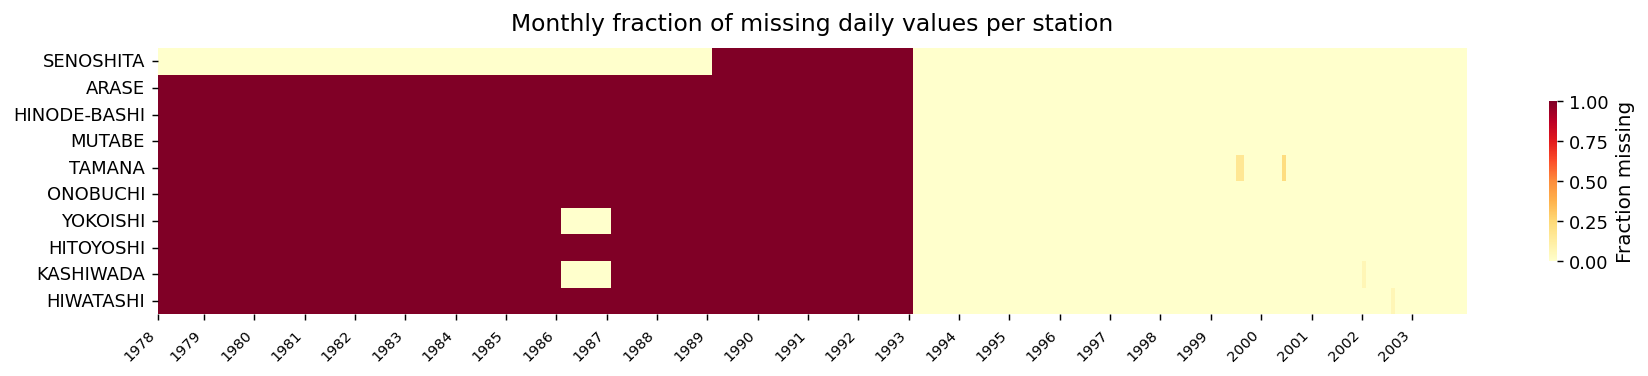

In [9]:
fig, ax = plt.subplots(figsize=(14, 3))

# Monthly fraction of missing values
miss_monthly = wide.resample("ME").apply(lambda x: x.isna().mean())

# Rename columns
miss_monthly.columns = [STATIONS[s]["name"] for s in miss_monthly.columns]

# Heatmap
sns.heatmap(
    miss_monthly.T,
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar_kws={"label": "Fraction missing", "shrink": 0.6},
)

ax.set_title("Monthly fraction of missing daily values per station", pad=10)

# Year ticks
years = miss_monthly.resample("YS").first().index
tick_pos = miss_monthly.index.get_indexer(years, method="nearest")

ax.set_xticks(tick_pos)
ax.set_xticklabels(
    [str(y.year) for y in years],
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_xlabel("")

plt.tight_layout()
plt.show()

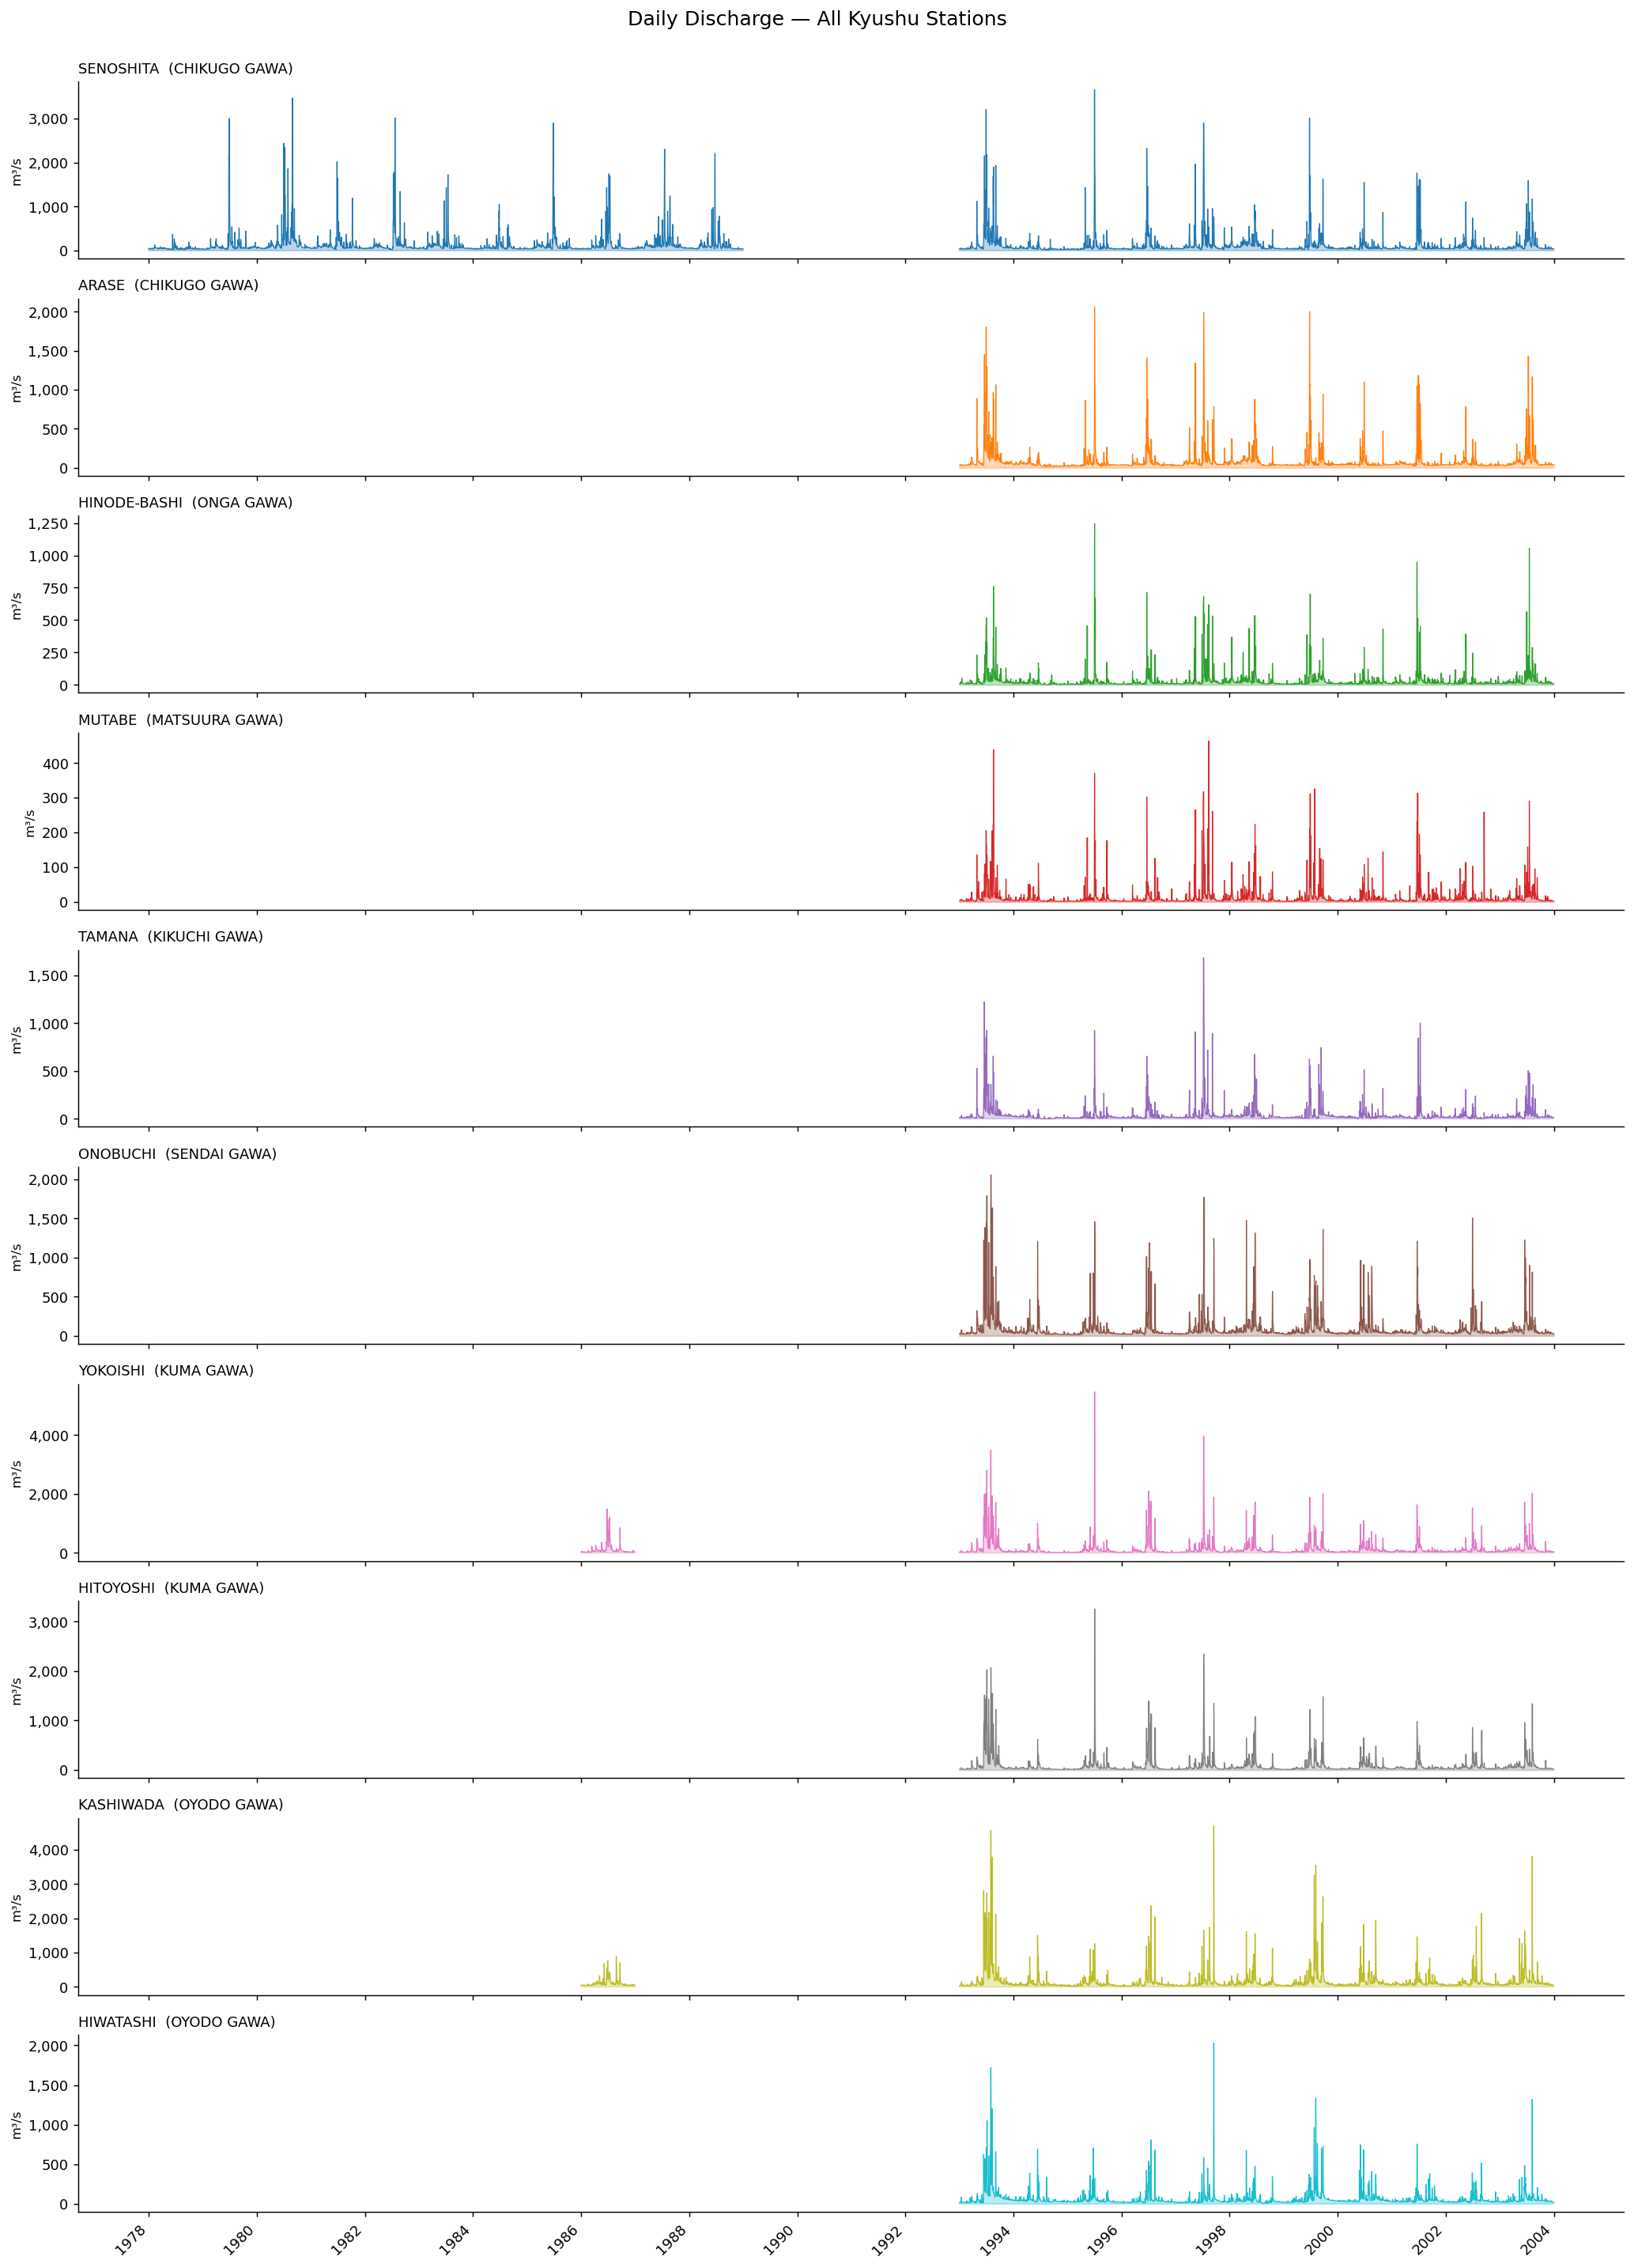

In [10]:
colors = plt.cm.tab10.colors
n = len(station_ids)

fig, axes = plt.subplots(n, 1, figsize=(16, 2.2 * n), sharex=True)

for i, (sid, ax) in enumerate(zip(station_ids, axes)):
    s = daily[sid]
    ax.fill_between(s.index, s.values, alpha=0.3, color=colors[i])
    ax.plot(s.index, s.values, lw=0.6, color=colors[i])
    ax.set_ylabel("m³/s", fontsize=9)
    ax.set_title(f"{STATIONS[sid]['name']}  ({STATIONS[sid]['river']})",
                 fontsize=10, loc="left")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
fig.suptitle("Daily Discharge — All Kyushu Stations", fontsize=14, y=1.001)
plt.tight_layout()
plt.show()

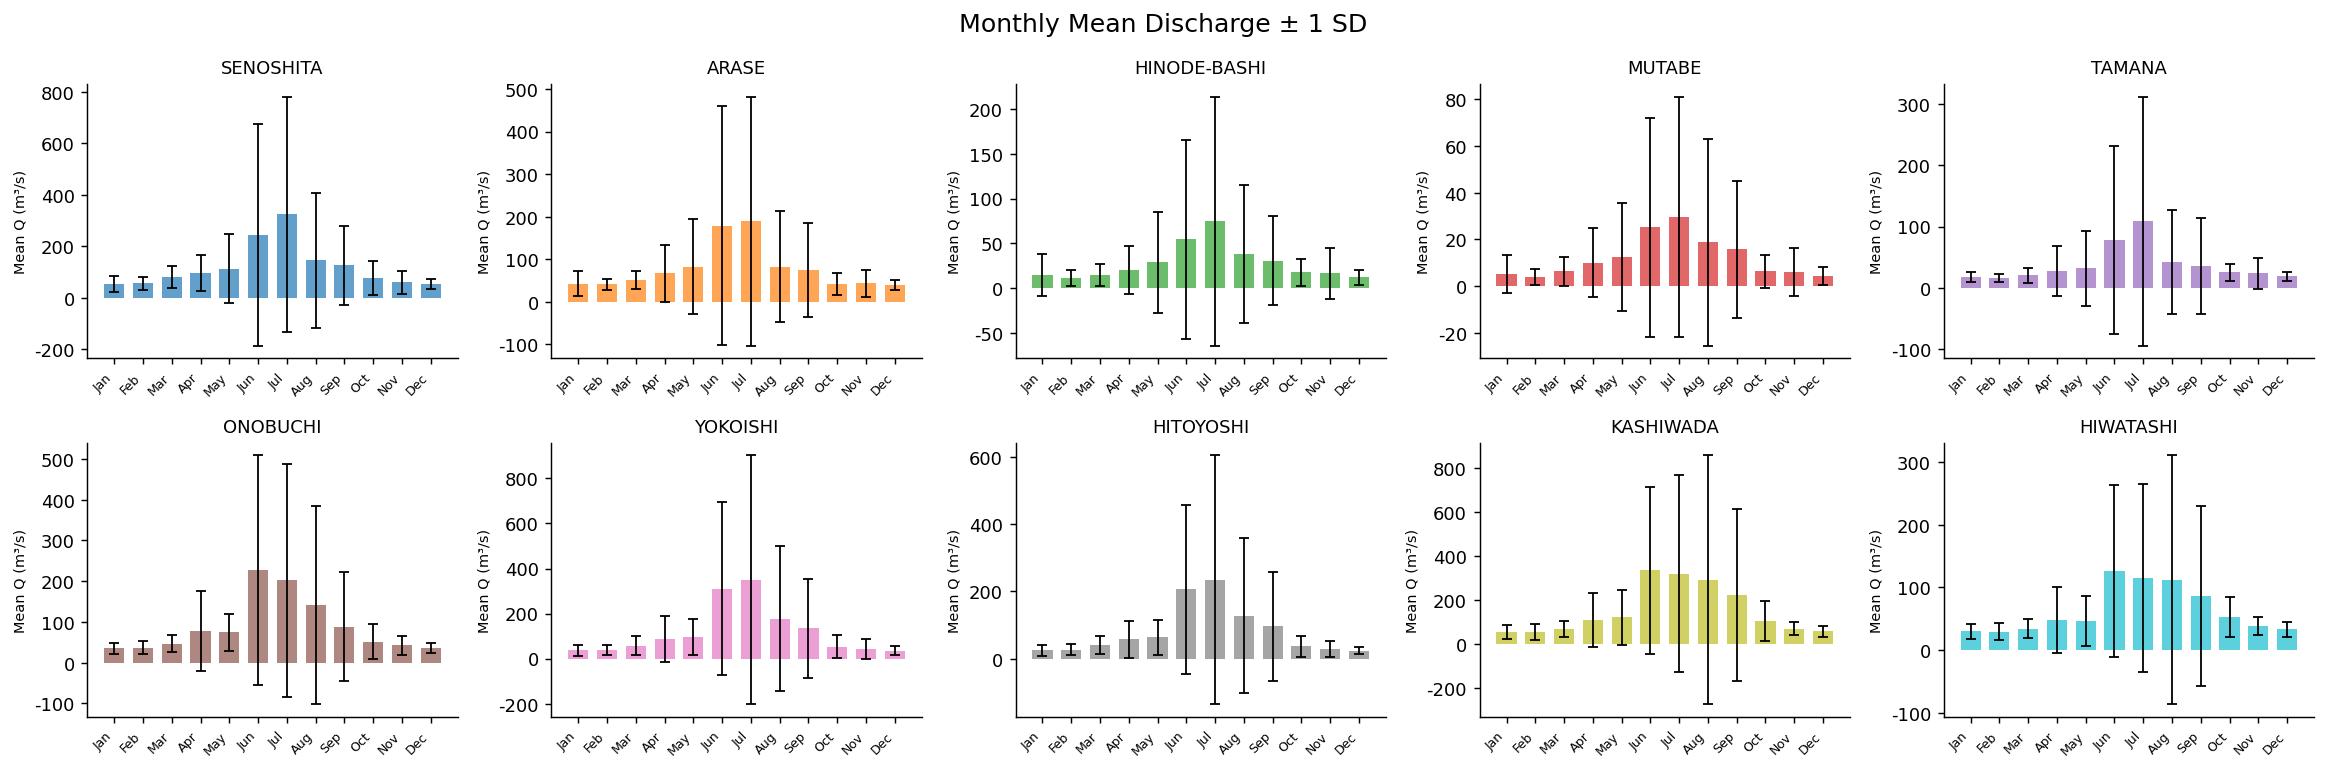

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharey=False)
axes = axes.flatten()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

for i, (sid, ax) in enumerate(zip(station_ids, axes)):
    s = daily[sid].dropna()
    monthly_mean = s.groupby(s.index.month).mean()
    monthly_std  = s.groupby(s.index.month).std()
    ax.bar(monthly_mean.index, monthly_mean.values,
           color=colors[i], alpha=0.7, width=0.7)
    ax.errorbar(monthly_mean.index, monthly_mean.values,
                yerr=monthly_std.values,
                fmt="none", color="black", capsize=3, lw=1)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45, ha="right", fontsize=7)
    ax.set_title(STATIONS[sid]["name"], fontsize=10)
    ax.set_ylabel("Mean Q (m³/s)", fontsize=8)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Monthly Mean Discharge ± 1 SD", fontsize=14)
plt.tight_layout()
plt.show()

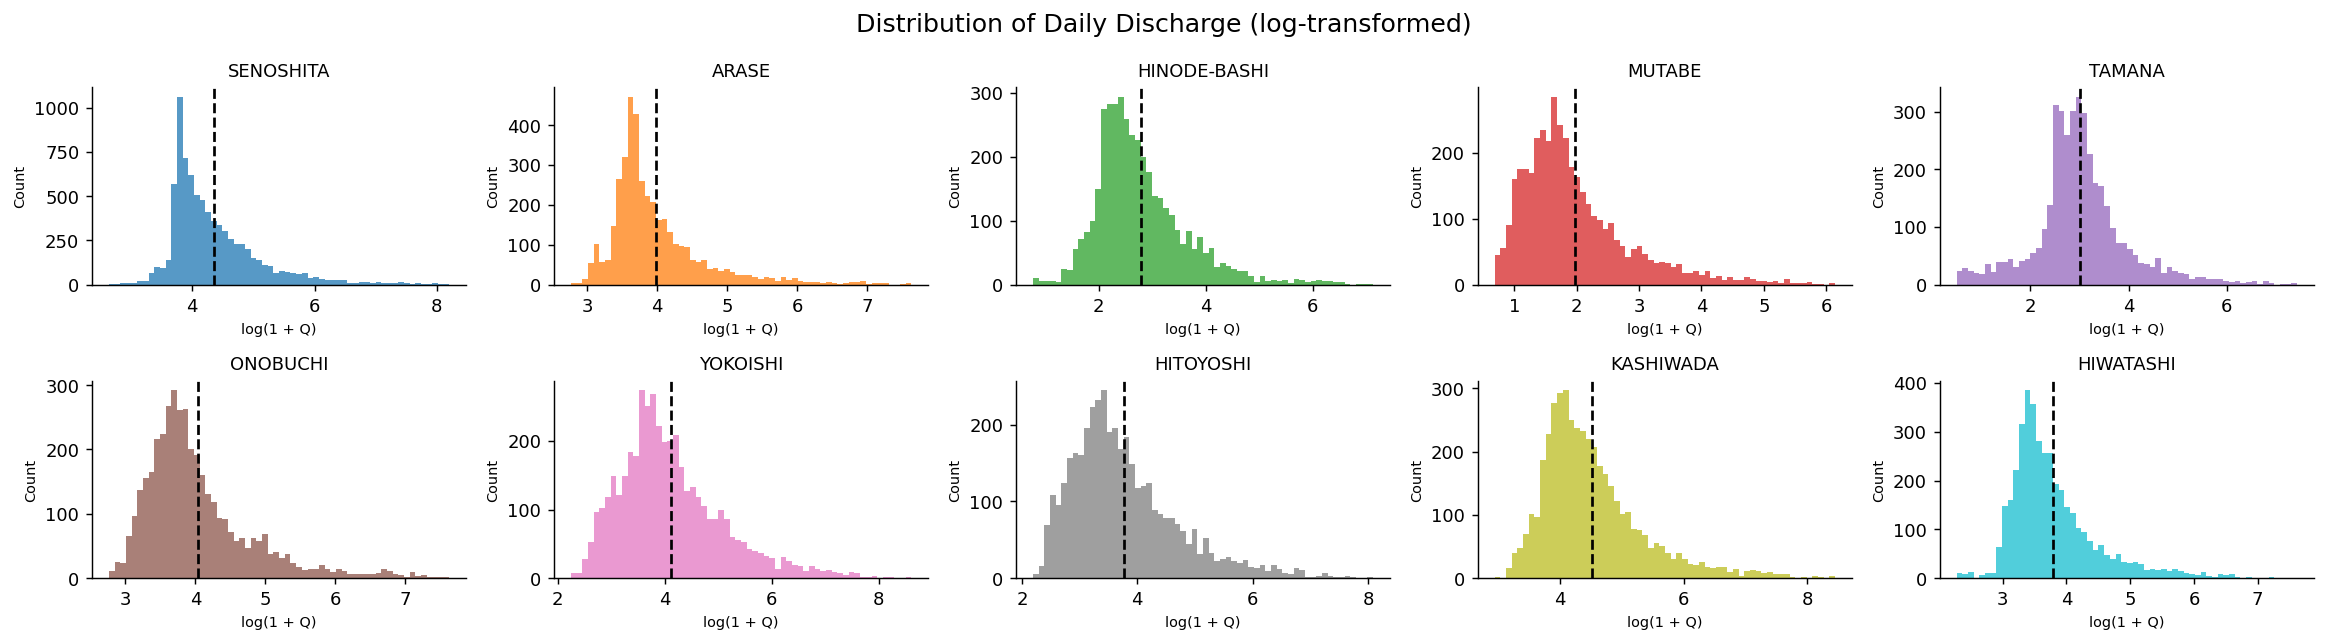

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()

for i, (sid, ax) in enumerate(zip(station_ids, axes)):
    s = np.log1p(daily[sid].dropna())
    ax.hist(s, bins=60, color=colors[i], alpha=0.75, edgecolor="none")
    ax.axvline(s.mean(), color="black", lw=1.5, linestyle="--")
    ax.set_title(STATIONS[sid]["name"], fontsize=10)
    ax.set_xlabel("log(1 + Q)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)

fig.suptitle("Distribution of Daily Discharge (log-transformed)", fontsize=14)
plt.tight_layout()
plt.show()

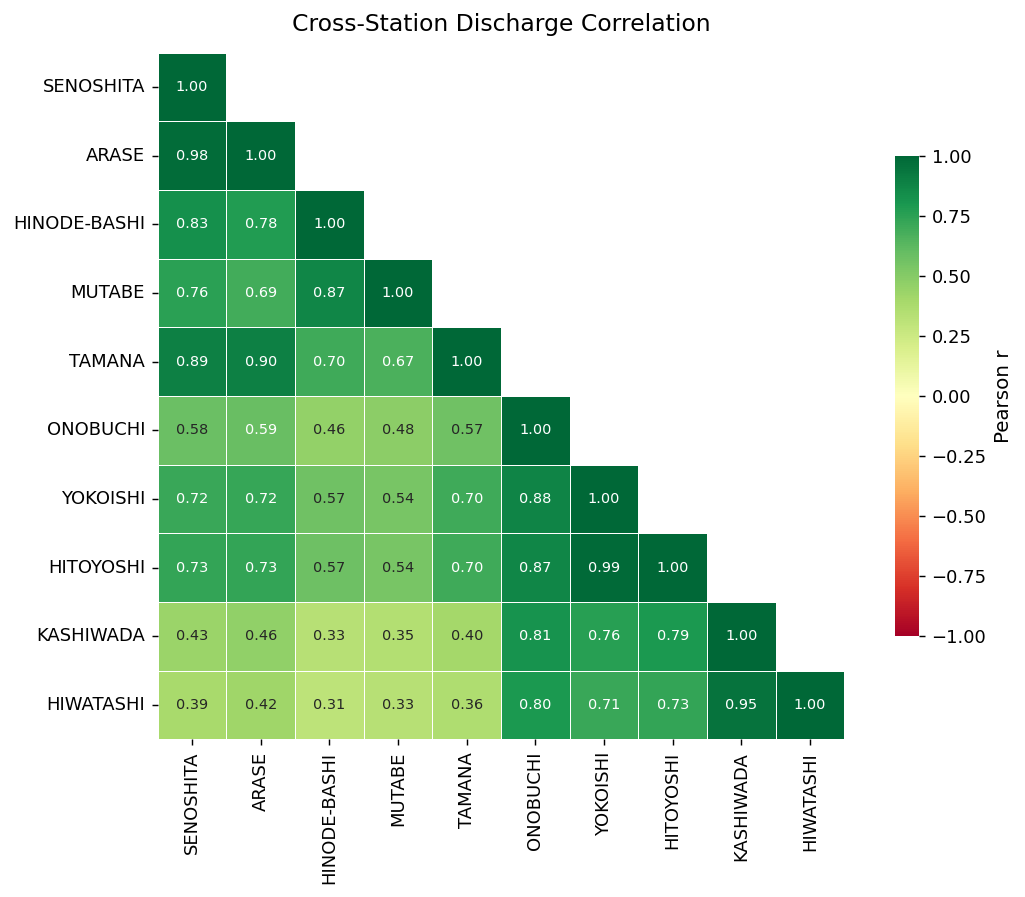

In [13]:
corr = wide.corr(min_periods=100)
corr.index   = [STATIONS[s]["name"] for s in corr.index]
corr.columns = [STATIONS[s]["name"] for s in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=ax, mask=mask,
    cmap="RdYlGn", vmin=-1, vmax=1, center=0,
    annot=True, fmt=".2f", annot_kws={"size": 8},
    linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
)
ax.set_title("Cross-Station Discharge Correlation", pad=12)
plt.tight_layout()
plt.show()

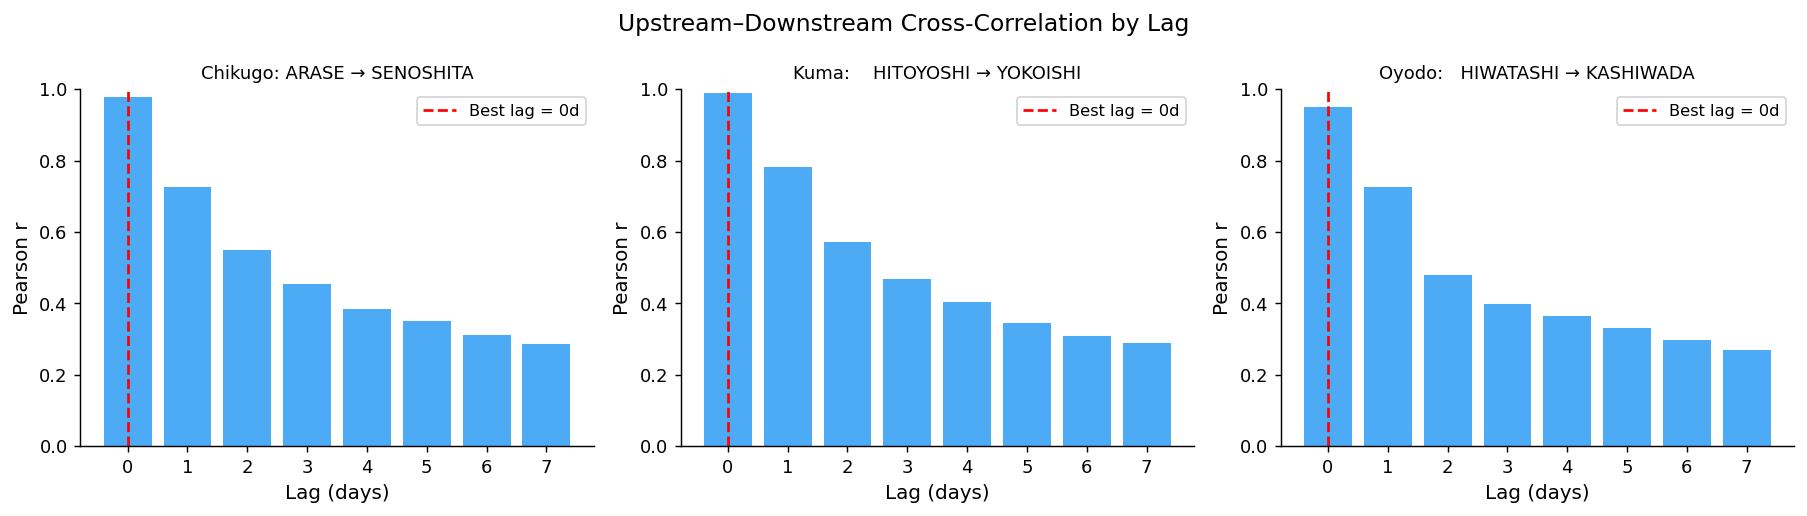

In [14]:
pairs = [
    ("2590101", "2590100", "Chikugo: ARASE → SENOSHITA"),
    ("2590301", "2590300", "Kuma:    HITOYOSHI → YOKOISHI"),
    ("2590401", "2590400", "Oyodo:   HIWATASHI → KASHIWADA"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (up_id, dn_id, title) in zip(axes, pairs):
    up = daily[up_id].dropna()
    dn = daily[dn_id].dropna()
    common = up.index.intersection(dn.index)
    up_c, dn_c = up[common], dn[common]

    lags  = range(0, 8)
    corrs = [up_c.corr(dn_c.shift(-lag)) for lag in lags]
    best  = int(np.argmax(corrs))

    ax.bar(list(lags), corrs, color="#2196F3", alpha=0.8)
    ax.axvline(best, color="red", lw=1.5, linestyle="--",
               label=f"Best lag = {best}d")
    ax.set_xlabel("Lag (days)")
    ax.set_ylabel("Pearson r")
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

fig.suptitle("Upstream–Downstream Cross-Correlation by Lag", fontsize=13)
plt.tight_layout()
plt.show()

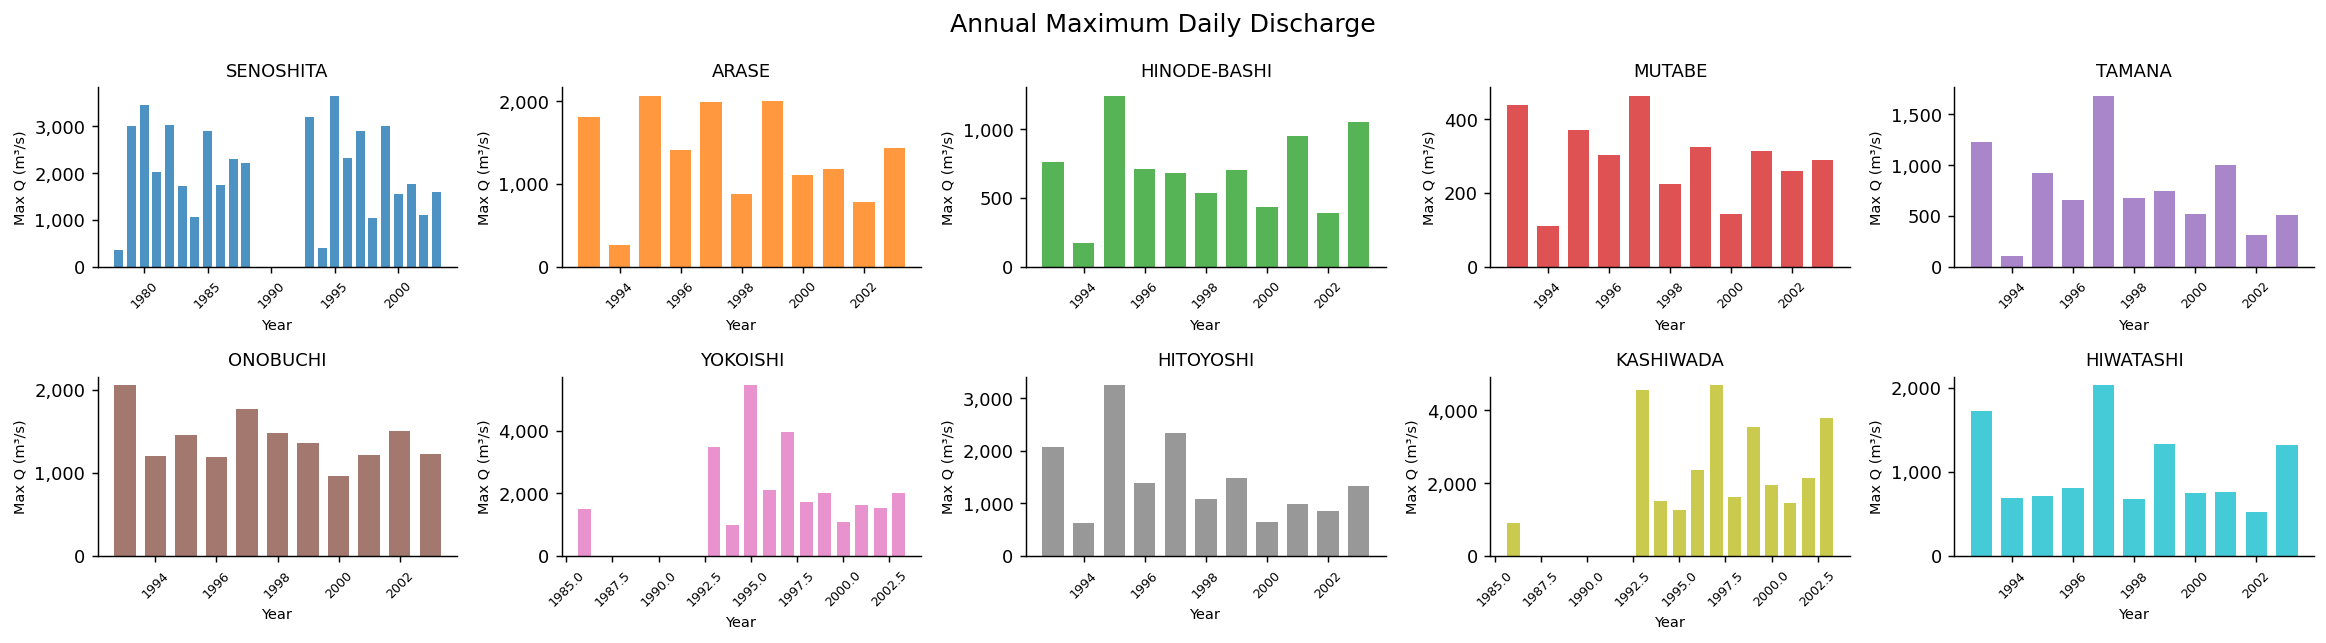

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()

for i, (sid, ax) in enumerate(zip(station_ids, axes)):
    ann_max = daily[sid].dropna().resample("YE").max()
    ax.bar(ann_max.index.year, ann_max.values,
           color=colors[i], alpha=0.8, width=0.7)
    ax.set_title(STATIONS[sid]["name"], fontsize=10)
    ax.set_xlabel("Year", fontsize=8)
    ax.set_ylabel("Max Q (m³/s)", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

fig.suptitle("Annual Maximum Daily Discharge", fontsize=14)
plt.tight_layout()
plt.show()

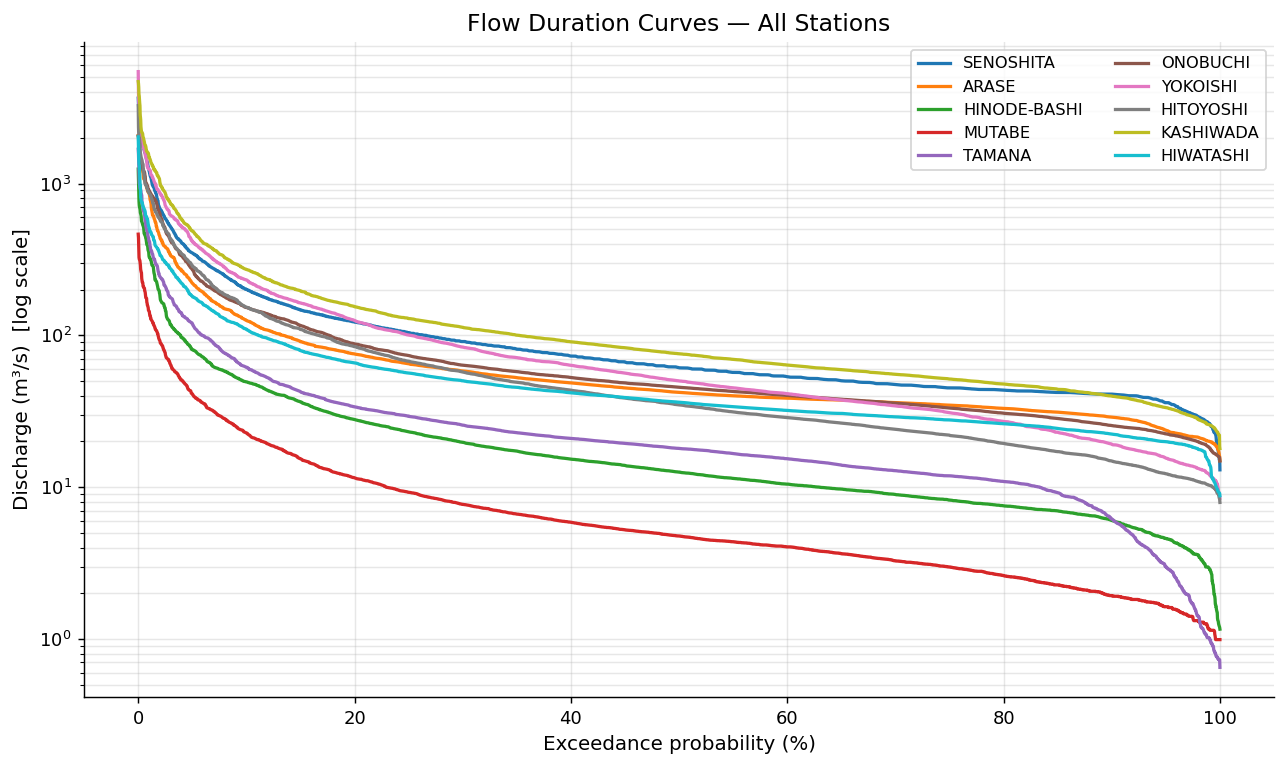

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, sid in enumerate(station_ids):
    s = daily[sid].dropna().sort_values(ascending=False)
    exceedance = np.linspace(0, 100, len(s))
    ax.semilogy(exceedance, s.values, lw=1.8,
                color=colors[i], label=STATIONS[sid]["name"])

ax.set_xlabel("Exceedance probability (%)")
ax.set_ylabel("Discharge (m³/s)  [log scale]")
ax.set_title("Flow Duration Curves — All Stations")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()